# 🧪 GELU Activation Experiment

**Goal**: Test if biologically-plausible GELU activation improves NER performance.

**What is GELU?**
- Gaussian Error Linear Unit
- Smooth, differentiable everywhere (unlike ReLU)
- Used in BERT, GPT (proven effective)
- More biologically plausible (stochastic neuron activation)

**This notebook is STANDALONE** - fresh Colab session, no previous runs needed!

## 1. Check GPU

In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU - training will be slow!")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


## 2. Clone Repository

In [3]:
import getpass

# Get your token securely (won't be visible in output)
token = getpass.getpass('Enter your GitHub Personal Access Token: ')

# Clone using token
!git clone https://{token}@github.com/bhushan1729/olfaction-inspired-ner.git
%cd olfaction-inspired-ner

Enter your GitHub Personal Access Token: ··········
Cloning into 'olfaction-inspired-ner'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 96 (delta 39), reused 77 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 336.04 KiB | 1.77 MiB/s, done.
Resolving deltas: 100% (39/39), done.
/content/olfaction-inspired-ner


## 3. Install Dependencies

In [4]:
!pip install -q torch numpy scikit-learn seqeval matplotlib seaborn pandas tqdm tensorboard requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 4. Download GloVe Embeddings

In [5]:
import os

if not os.path.exists('./data/glove.6B.300d.txt'):
    print("Downloading GloVe embeddings (takes ~5 min)...")
    !mkdir -p data
    !wget -q http://nlp.stanford.edu/data/glove.6B.zip -O data/glove.6B.zip
    !unzip -q data/glove.6B.zip -d data/
    !rm data/glove.6B.zip
    print("✓ GloVe downloaded")
else:
    print("✓ GloVe already exists")

✓ GloVe downloaded


## 5. Fix Python Path

In [6]:
import sys
sys.path.append('/content/olfaction-inspired-ner')
print("✓ Path configured")

✓ Path configured


## 6. Train with GELU Activation

This will:
- Download CoNLL-2003 automatically
- Train olfactory model with **GELU** activation in receptors
- Takes ~20-30 minutes on GPU

In [7]:
# Train with GELU
!python src/train.py \
  --config config/tuning_experiments.yaml \
  --experiment activation_gelu \
  --save_dir results/tuning/gelu

2026-01-12 09:13:40.443102: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768209220.462983    2999 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768209220.468920    2999 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768209220.483993    2999 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768209220.484018    2999 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768209220.484029    2999 computation_placer.cc:177] computation placer alr

## 7. View Results

In [8]:
import json

# Load results
with open('results/tuning/gelu/results.json') as f:
    results = json.load(f)

print("\n" + "="*60)
print(" "*15 + "GELU EXPERIMENT RESULTS")
print("="*60)

test = results['test']
print(f"\nTest F1:        {test['f1']:.4f}")
print(f"Precision:      {test['precision']:.4f}")
print(f"Recall:         {test['recall']:.4f}")

print("\nPer-entity F1 scores:")
print("-" * 60)
for entity, score in test['per_entity'].items():
    if entity in ['LOC', 'MISC', 'ORG', 'PER']:
        print(f"  {entity:<10} {score:.4f}")

print("\n" + "="*60)
print("\n✓ Training complete!")
print("\nShare these results with the comparison task.")


               GELU EXPERIMENT RESULTS

Test F1:        0.7306
Precision:      0.7873
Recall:         0.6815

Per-entity F1 scores:
------------------------------------------------------------
  LOC        0.8082
  MISC       0.6761
  ORG        0.7067
  PER        0.6914


✓ Training complete!

Share these results with the comparison task.


## 8. Analyze Receptor Activations (Optional)

In [9]:
# Analyze what receptors learned with GELU
import torch
from src.data.dataset import prepare_data
from src.model.olfactory_ner import create_olfactory_ner
from src.analysis.visualize import analyze_receptor_activations
import yaml

# Load config
with open('config/tuning_experiments.yaml') as f:
    config = yaml.safe_load(f)

exp_config = config['activation_gelu']
exp_config.update(config['data'])

# Load data
print("Loading data...")
_, _, test_loader, vocab_info = prepare_data(
    data_dir='./data/raw',
    batch_size=32
)

# Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(
    'results/tuning/gelu/best_model.pt',
    map_location=device,
    weights_only=False
)

vocab_size = len(vocab_info['word2idx'])
num_tags = len(vocab_info['label2idx'])

model = create_olfactory_ner(vocab_size, num_tags, exp_config)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

# Analyze
print("\nAnalyzing GELU receptor activations...")
analyze_receptor_activations(
    model,
    test_loader,
    vocab_info,
    device,
    save_dir='./analysis_gelu'
)

print("\n✓ Analysis complete! Check analysis_gelu/ folder")

Loading data...
Loading training data...
Loading validation data...
Loading test data...
Train: 14041 sentences
Valid: 3250 sentences
Test: 3453 sentences

Building vocabularies...
Vocabulary size: 11984
Number of labels: 8
Labels: ['B-LOC', 'B-MISC', 'B-ORG', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']

Analyzing GELU receptor activations...
Creating receptor activation heatmap...
Finding top activating tokens per receptor...

Top 5 receptors and their top tokens:

Receptor 0:
  said: 7.352
  said: 7.352
  said: 7.352
  said: 7.352
  said: 7.352

Receptor 1:
  3: 11.951
  3: 11.951
  3: 11.951
  3: 11.951
  3: 11.951

Receptor 2:
  said: 7.909
  said: 7.909
  said: 7.909
  said: 7.909
  said: 7.909

Receptor 3:
  3: 6.901
  3: 6.901
  3: 6.901
  3: 6.901
  3: 6.901

Receptor 4:
  5.: 6.717
  5.: 6.717
  5.: 6.717
  5.: 6.717
  5.: 6.717

Creating t-SNE visualization...

Computing receptor specialization metrics...
Receptor activation sparsity: 26.44%
Average activation (when active): 0.

## 9. Display Visualizations (Optional)

📊 Receptor Activation Heatmap (GELU):


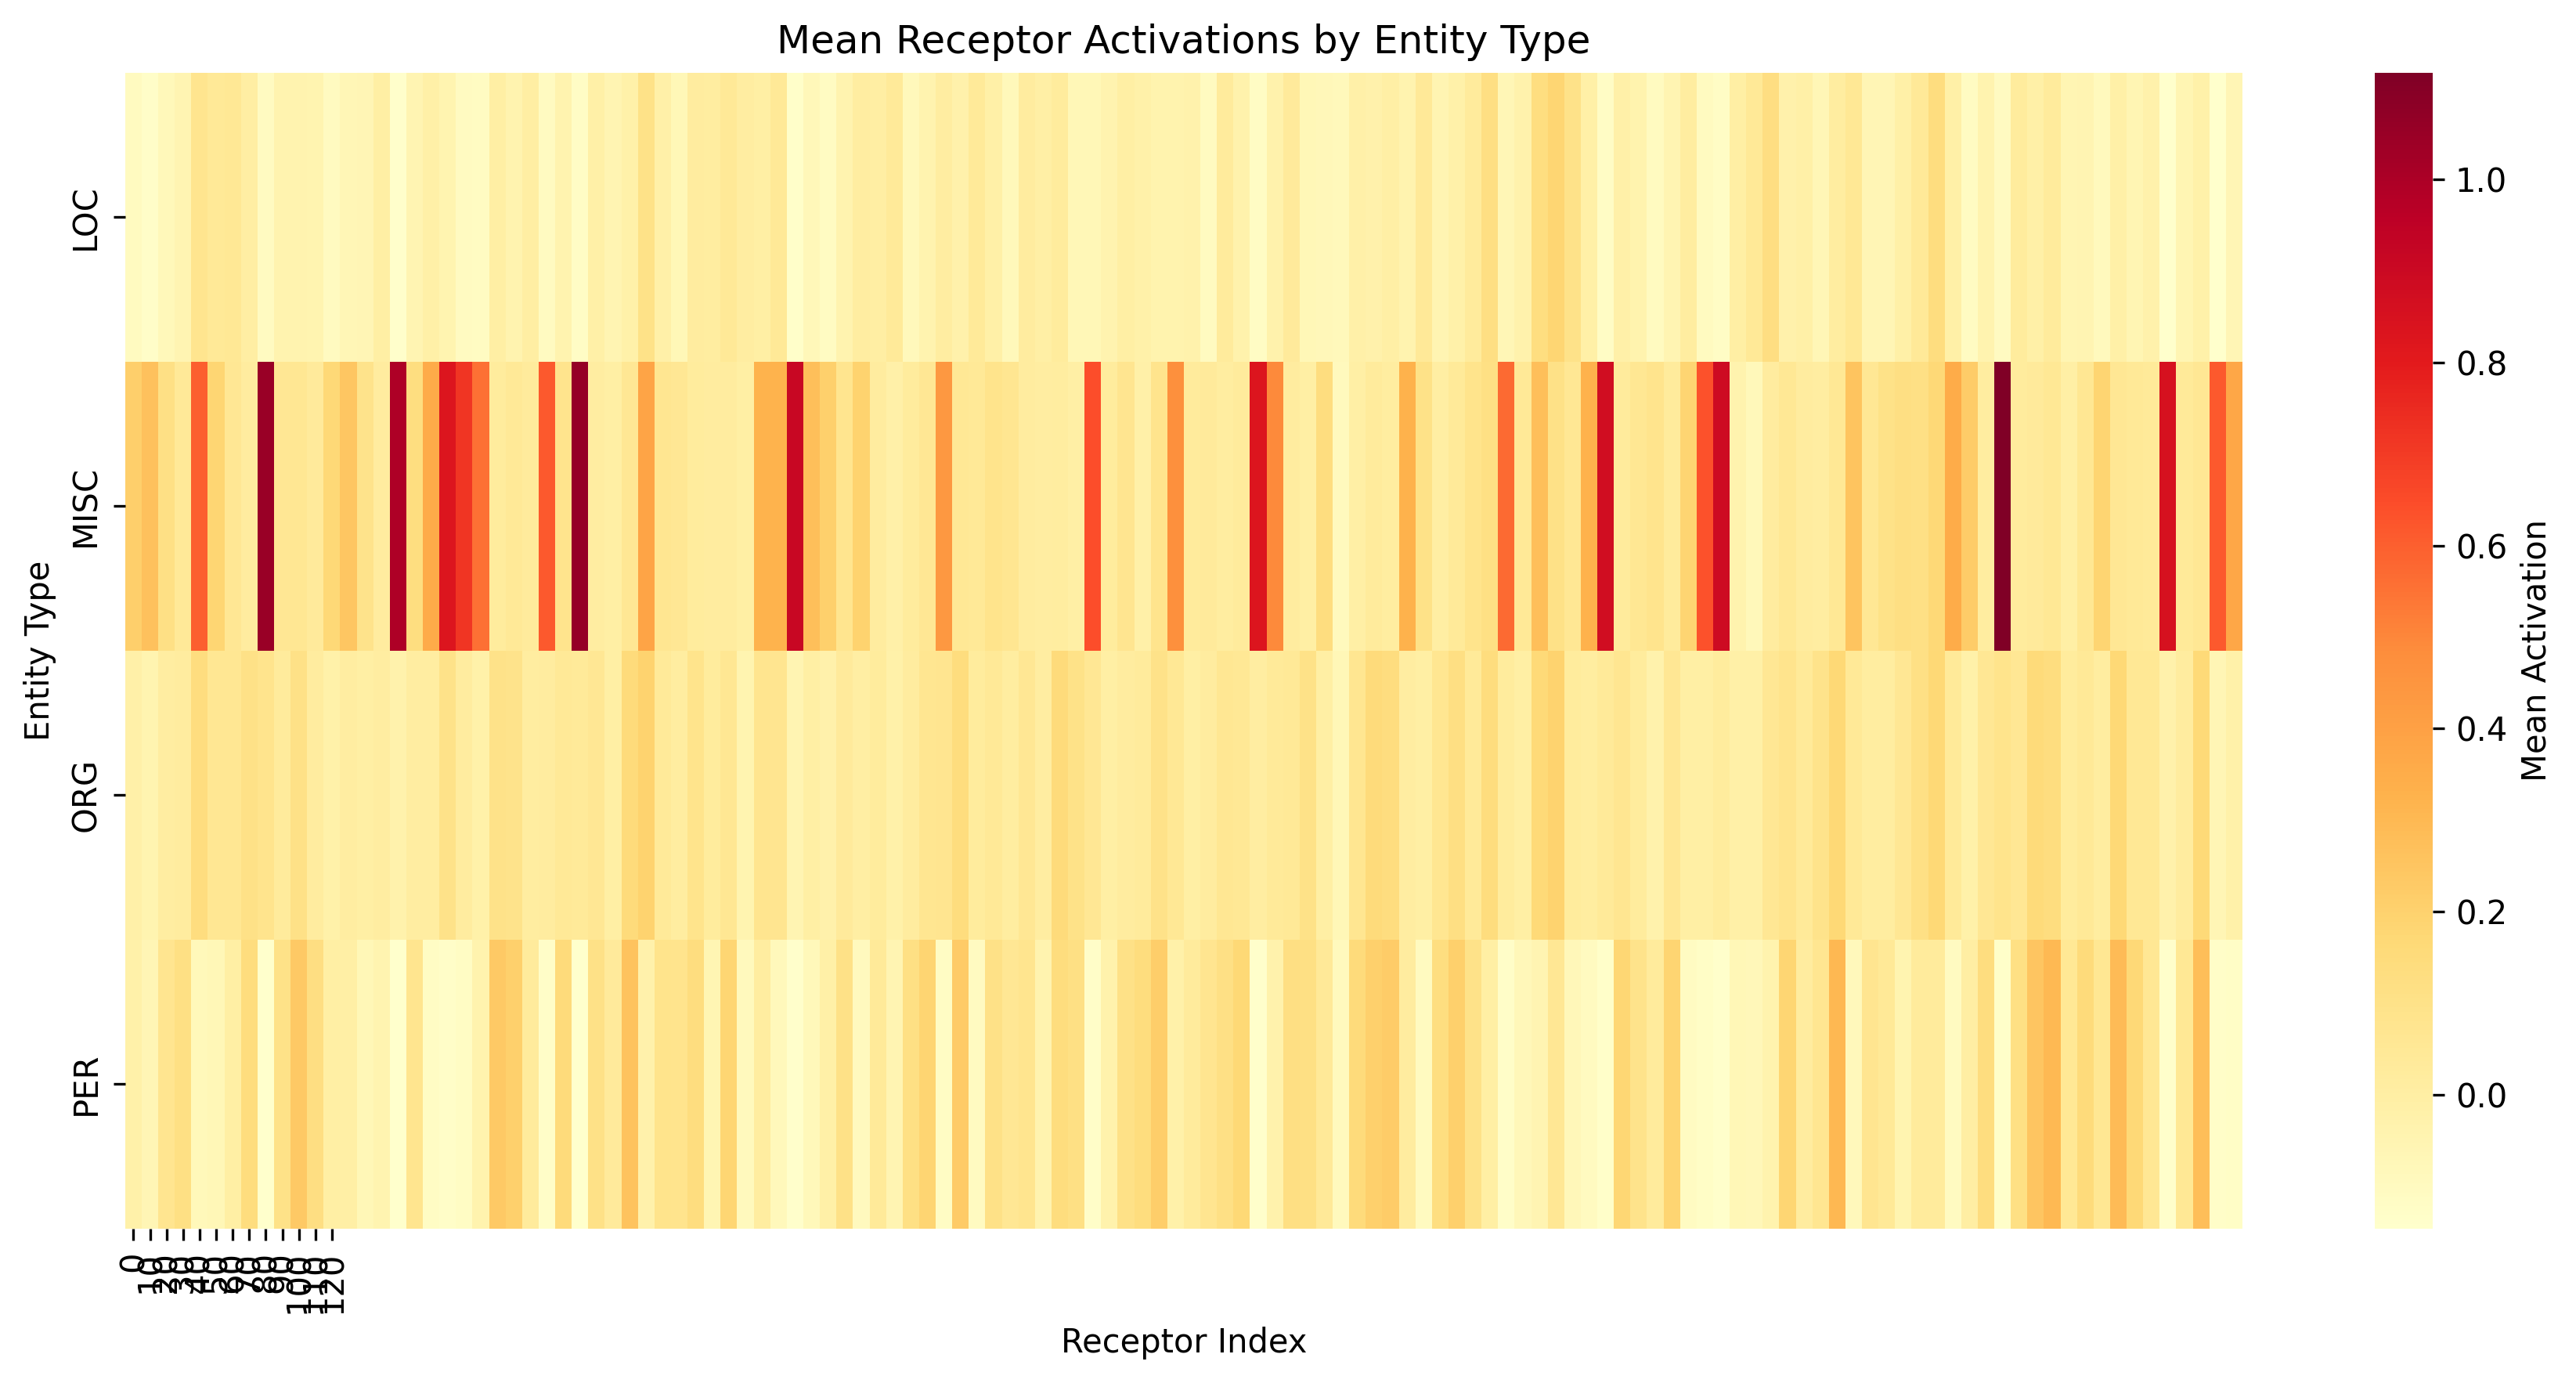


📊 t-SNE Visualization (GELU):


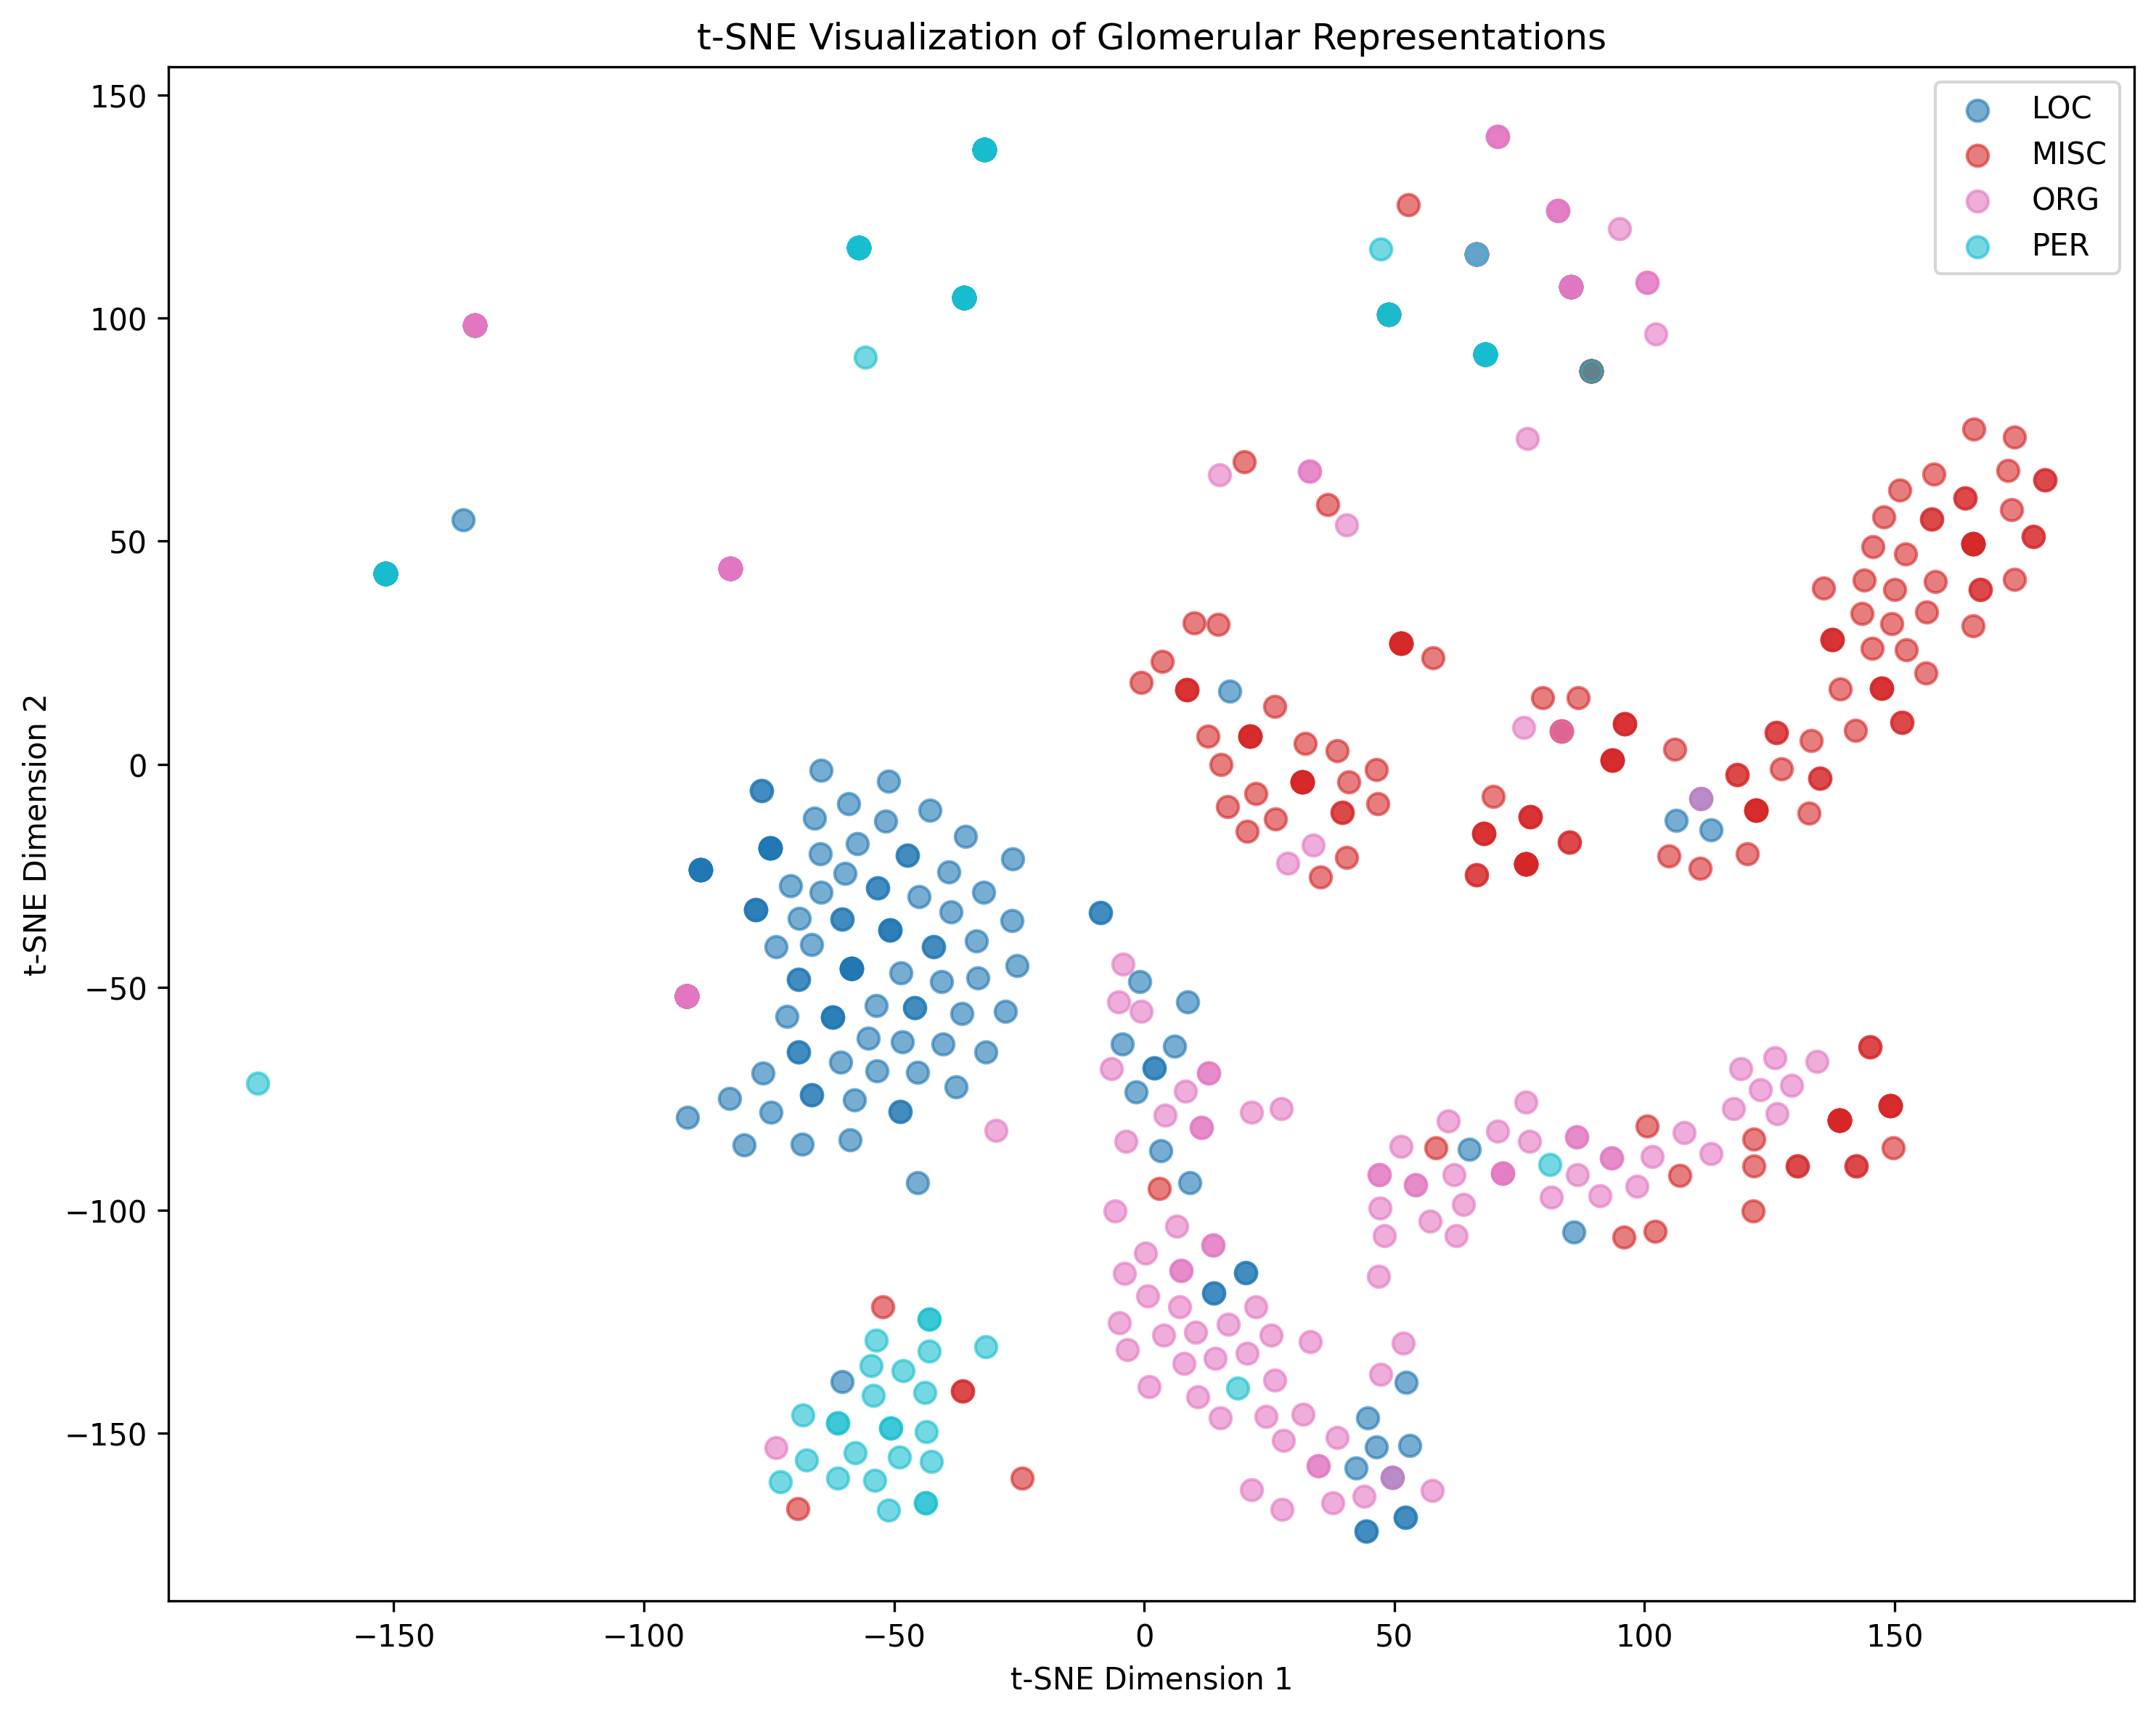

In [10]:
from IPython.display import Image, display

print("📊 Receptor Activation Heatmap (GELU):")
display(Image('analysis_gelu/receptor_heatmap.png'))

print("\n📊 t-SNE Visualization (GELU):")
display(Image('analysis_gelu/glomeruli_tsne.png'))

## 10. Download Results

In [11]:
# Package everything
!zip -r gelu_experiment_results.zip results/tuning/gelu/ analysis_gelu/

# Download
from google.colab import files
files.download('gelu_experiment_results.zip')

print("\n✓ Results downloaded!")

  adding: results/tuning/gelu/ (stored 0%)
  adding: results/tuning/gelu/best_model.pt (deflated 6%)
  adding: results/tuning/gelu/results.json (deflated 75%)
  adding: analysis_gelu/ (stored 0%)
  adding: analysis_gelu/receptor_analysis.json (deflated 94%)
  adding: analysis_gelu/glomeruli_tsne.png (deflated 13%)
  adding: analysis_gelu/receptor_heatmap.png (deflated 30%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Results downloaded!


---

## 📋 Summary

**What you have now:**
- ✅ GELU model trained on CoNLL-2003
- ✅ Test F1 score (shown above)
- ✅ Per-entity performance
- ✅ Receptor activation visualizations
- ✅ All results downloaded

**Next step:**
Provide these results to compare with ReLU baseline!